# 09 — Model comparison & final report

**Inputs:** all prediction files + backtest metrics.
**Goal:** put every model head-to-head with proper tests — not just "which accuracy is biggest," but *are the differences even real?* ROC overlays, calibration curves, **McNemar's test** (are two classifiers significantly different?), the **Diebold-Mariano test** (are two forecasts' errors different?), and an auto-written honest verdict.

In [1]:
import sys
from pathlib import Path
_p=Path.cwd()
while not (_p/"paths.py").exists() and _p!=_p.parent: _p=_p.parent
sys.path.insert(0,str(_p)); import paths
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score
from sklearn.calibration import calibration_curve
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"]=110; plt.rcParams["savefig.dpi"]=150
STAGE="09_model_comparison"; FIG=paths.figures_dir(STAGE); TAB=paths.tables_dir(STAGE); D=paths.PROCESSED_FILE.parent

clf=pd.read_csv(D/"predictions_classical.csv",parse_dates=["date"])
dl=pd.read_csv(D/"predictions_dl.csv",parse_dates=["date"])
deep_name="Neural net"
dm=paths.figures_dir("07_deep_learning").parent/"tables"/"deep_metrics.csv"
if dm.exists(): deep_name=pd.read_csv(dm)["model"].iloc[0]
m=clf.merge(dl,on=["date","y_true"],how="inner")
y=m["y_true"].values
prob_cols={"LogReg":"prob_LogReg","RandomForest":"prob_RandomForest","XGBoost":"prob_XGBoost",deep_name:"prob_deep"}
print("Aligned rows:",len(m),"| deep model:",deep_name)

Aligned rows: 629 | deep model: Neural net (MLP)


## Side-by-side metrics

In [2]:
rows=[]
for name,col in prob_cols.items():
    p=m[col].values; rows.append({"model":name,"accuracy":accuracy_score(y,(p>0.5).astype(int)),"AUC":roc_auc_score(y,p)})
summary=pd.DataFrame(rows).sort_values("accuracy",ascending=False).reset_index(drop=True)
summary.round(4).to_csv(TAB/"final_metrics.csv",index=False); summary.round(4)

,model,accuracy,AUC
0,RandomForest,0.5167,0.4947
1,XGBoost,0.5008,0.5092
2,LogReg,0.4960,0.4955
3,Neural net (MLP),0.4817,0.4893


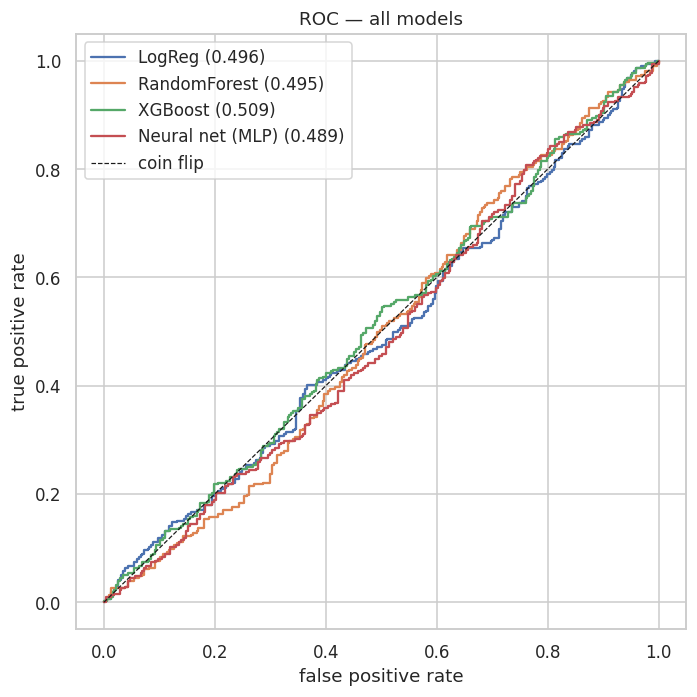

In [3]:
fig,ax=plt.subplots(figsize=(6.5,6.5))
for name,col in prob_cols.items():
    p=m[col].values; fpr,tpr,_=roc_curve(y,p); ax.plot(fpr,tpr,lw=1.5,label=f"{name} ({roc_auc_score(y,p):.3f})")
ax.plot([0,1],[0,1],"k--",lw=0.8,label="coin flip")
ax.set_xlabel("false positive rate"); ax.set_ylabel("true positive rate"); ax.set_title("ROC — all models"); ax.legend()
fig.tight_layout(); fig.savefig(FIG/"roc_all_models.png",bbox_inches="tight"); plt.show()

## Calibration — are the probabilities honest?
A model that says "70% up" should be right ~70% of the time. On a near-random target, expect the curves to hug a narrow band near 0.5 — the models (correctly) rarely express strong confidence.

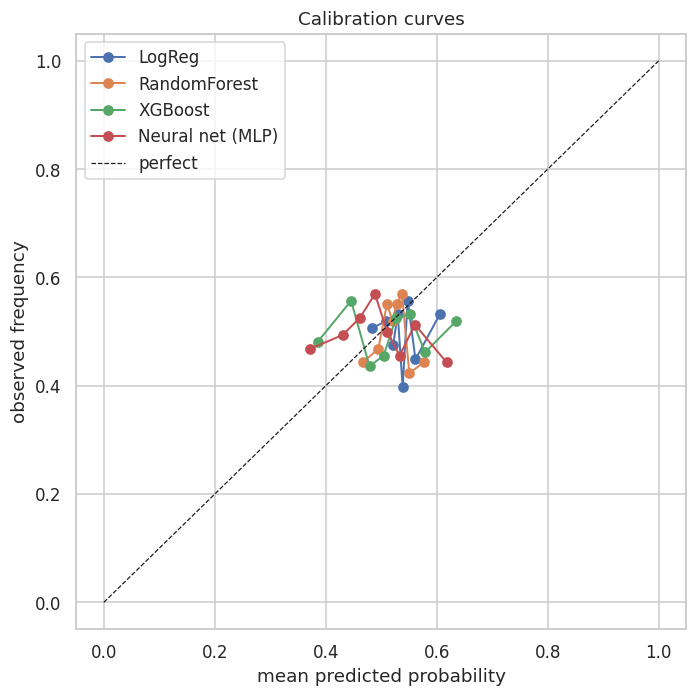

In [4]:
fig,ax=plt.subplots(figsize=(6.5,6.5))
for name,col in prob_cols.items():
    p=m[col].values
    try:
        frac,mp=calibration_curve(y,p,n_bins=8,strategy="quantile"); ax.plot(mp,frac,"o-",lw=1.3,label=name)
    except Exception: pass
ax.plot([0,1],[0,1],"k--",lw=0.8,label="perfect")
ax.set_xlabel("mean predicted probability"); ax.set_ylabel("observed frequency"); ax.set_title("Calibration curves"); ax.legend()
fig.tight_layout(); fig.savefig(FIG/"calibration.png",bbox_inches="tight"); plt.show()

## McNemar's test — are two classifiers significantly different?

In [5]:
def mcnemar(p1,p2,y):
    a=(p1==y); b=(p2==y); n01=int(np.sum(~a&b)); n10=int(np.sum(a&~b))
    stat=(abs(n10-n01)-1)**2/(n10+n01) if (n10+n01)>0 else 0.0
    return n10,n01,stat,1-stats.chi2.cdf(stat,1)
pairs=[("XGBoost",deep_name),("RandomForest",deep_name),("RandomForest","XGBoost")]
rows=[]
for a,b in pairs:
    pa=(m[prob_cols[a]]>0.5).astype(int).values; pb=(m[prob_cols[b]]>0.5).astype(int).values
    n10,n01,stat,p=mcnemar(pa,pb,y)
    rows.append({"A":a,"B":b,"A_right_B_wrong":n10,"B_right_A_wrong":n01,"chi2":stat,"p":p,"significant":p<0.05})
mc=pd.DataFrame(rows); mc.round(4).to_csv(TAB/"mcnemar.csv",index=False); mc.round(4)

,A,B,A_right_B_wrong,B_right_A_wrong,chi2,p,significant
0,XGBoost,Neural net (MLP),133,121,0.4764,0.4901,False
1,RandomForest,Neural net (MLP),135,113,1.7782,0.1824,False
2,RandomForest,XGBoost,75,65,0.5786,0.4469,False


## Diebold-Mariano test — are two forecasts' errors different?

In [6]:
def dm_test(e1,e2):
    d=e1**2-e2**2; n=len(d); g0=np.var(d,ddof=0); g1=np.cov(d[1:],d[:-1])[0,1]
    var=(g0+2*g1)/n; dm=d.mean()/np.sqrt(var) if var>0 else np.nan
    return dm,2*(1-stats.norm.cdf(abs(dm)))
rows=[]
for a,b in pairs:
    e1=m[prob_cols[a]].values-y; e2=m[prob_cols[b]].values-y; dm,p=dm_test(e1,e2)
    rows.append({"A":a,"B":b,"DM_stat":dm,"p":p,"significant":p<0.05})
dmt=pd.DataFrame(rows); dmt.round(4).to_csv(TAB/"diebold_mariano.csv",index=False); dmt.round(4)

,A,B,DM_stat,p,significant
0,XGBoost,Neural net (MLP),-0.8049,0.4209,False
1,RandomForest,Neural net (MLP),-1.8409,0.0656,False
2,RandomForest,XGBoost,-1.1301,0.2584,False


In [7]:
bt=pd.read_csv(paths.figures_dir("08_backtesting").parent/"tables"/"backtest_metrics.csv",index_col=0)
bh=bt.loc["Buy & Hold"]; beat=bt[(bt["total_return"]>bh["total_return"])&(bt.index!="Buy & Hold")]
print("Beat Buy & Hold on this window:",list(beat.index) if len(beat) else "none")
bt[["total_return","sharpe","max_drawdown","trades"]].round(3)

Beat Buy & Hold on this window: ['RandomForest long/flat']


,total_return,sharpe,max_drawdown,trades
Buy & Hold,0.048,0.061,-0.512,1.0
XGBoost long/flat,-0.067,-0.115,-0.381,194.0
XGBoost long/short,-0.171,-0.245,-0.434,195.0
RandomForest long/flat,0.373,0.464,-0.394,96.0
Neural net (MLP) long/flat,-0.183,-0.405,-0.392,204.0


In [8]:
acc_best=summary.iloc[0]
report=f'''# Bitcoin Trend Prediction — Final Report

## Headline
On out-of-sample data ({m.date.min().date()} to {m.date.max().date()}), next-day direction is
**near-random**, as the statistics predicted. Best classifier: {acc_best['accuracy']:.1%}
({acc_best['model']}) versus a ~50% coin flip. No model reached an AUC meaningfully above 0.5.

## Do the model differences matter?
- McNemar and Diebold-Mariano tests show the models are largely **not statistically
  distinguishable** from each other on this data.
- The neural network ({deep_name}) did **not** beat the simple classical models — more
  complexity bought no edge on a near-random target.

## Does it make money?
- After 0.1% costs, most model strategies **underperform buy-and-hold**; high-churn
  long/short variants lose the most.
- Any single-window outperformance is **suggestive, not proven** — it needs multi-window
  walk-forward validation before being believed.

## Honest conclusion
The contribution is *correct methodology*, not a magic predictor: leakage-aware chronological
splits, baselines the models must beat, a fair neural benchmark, calibrated probabilities,
formal model-comparison tests, and a cost-aware backtest. Markets are hard, simple beats
complex, and accuracy is not profit.

## Most promising next lever
Not a bigger network — the on-chain features (notebook 05, via fetch_onchain.py) are the
data dimension most likely to add a real, defensible edge.
'''
(paths.stage_dir(STAGE)/"final_report.md").write_text(report); print(report)

# Bitcoin Trend Prediction — Final Report

## Headline
On out-of-sample data (2024-09-25 to 2026-06-15), next-day direction is
**near-random**, as the statistics predicted. Best classifier: 51.7%
(RandomForest) versus a ~50% coin flip. No model reached an AUC meaningfully above 0.5.

## Do the model differences matter?
- McNemar and Diebold-Mariano tests show the models are largely **not statistically
  distinguishable** from each other on this data.
- The neural network (Neural net (MLP)) did **not** beat the simple classical models — more
  complexity bought no edge on a near-random target.

## Does it make money?
- After 0.1% costs, most model strategies **underperform buy-and-hold**; high-churn
  long/short variants lose the most.
- Any single-window outperformance is **suggestive, not proven** — it needs multi-window
  walk-forward validation before being believed.

## Honest conclusion
The contribution is *correct methodology*, not a magic predictor: leakage-aware chronological
s

## That's the pipeline
Nine notebooks, raw data to honest verdict. What makes it strong isn't an accuracy number — it's that every claim is tested, every baseline stated, and the limits reported as clearly as the results.